In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from data.utils import plot_features_dual_axis


In [2]:
train = pd.read_csv("data/train.csv")
print("Train shape:", train.shape )
train.head(1)

Train shape: (439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0


In [3]:
test = pd.read_csv("data/test.csv")
print("Test shape:", test.shape )
test.head(1)

Test shape: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.28,-4.984,0.403846,0.0


# Feature Engineering

The raw columns describe a single lap on its own. I added context: compound norms, race position, strategy expectations, pit timing history, recent pace.

Each section below builds one feature on train and test, then plots it. Blue bars are the distribution. The orange line is the pit rate. If the orange line tracks the feature, the feature has signal.

## stint_progress

TyreLife of 20 means different things on SOFT and HARD. I normalized it per compound, dividing by the 75th-percentile TyreLife seen on rows that pitted next lap. A value near 1.0 means about as worn as a typical driver pitting on that compound.

In [4]:
expected_life = train.loc[train['PitNextLap'] == 1].groupby('Compound')['TyreLife'].quantile(0.75)
train['stint_progress'] = train['TyreLife'] / train['Compound'].map(expected_life)
test['stint_progress']  = test['TyreLife']  / test['Compound'].map(expected_life)
expected_life

Compound
HARD            27.00
INTERMEDIATE    24.00
MEDIUM          22.00
SOFT            16.00
WET             16.75
Name: TyreLife, dtype: float64

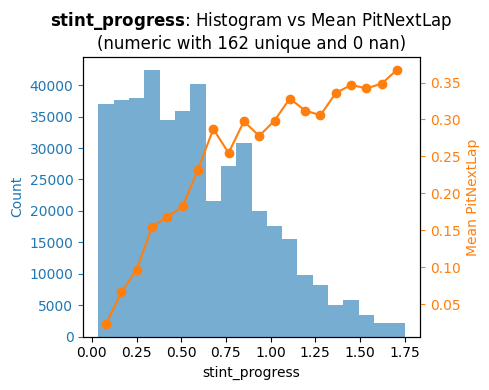

In [5]:
# clip the top 1% for display so the distribution shape is visible (a few rows > 2 squash the bins)
m = train['stint_progress'] <= train['stint_progress'].quantile(0.99)
plot_features_dual_axis(train[m], cols=['stint_progress'], target_col='PitNextLap', n_bins=20, n_wide=1)

## laps_remaining_frac

This is 1 minus RaceProgress. Pits cluster in the middle of a race. Too early gives no benefit, too late the drivers run to the finish. I expected the orange line to peak in the middle and drop at both ends.

In [6]:
train['laps_remaining_frac'] = 1 - train['RaceProgress']
test['laps_remaining_frac']  = 1 - test['RaceProgress']

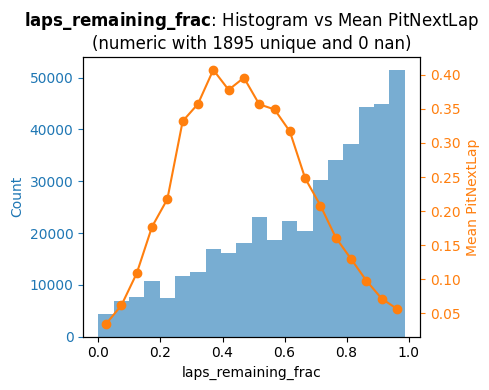

In [7]:
plot_features_dual_axis(train, cols=['laps_remaining_frac'], target_col='PitNextLap', n_bins=20, n_wide=1)

## p_one_stop

I grouped rows by current Stint and RaceProgress quartile, then took the fraction of drivers in that bucket who ran a 1-stop race. Total stops is max Stint minus 1, clipped. Each row gets its bucket value. I also built the 2-stop and 3-plus-stop versions but dropped them. They sum to one with p_one_stop and added no independent signal.

In [8]:
strategy = (train.groupby(['Race', 'Year', 'Driver'])['Stint'].transform('max') - 1).clip(lower=1, upper=3)
rp_bucket = pd.cut(train['RaceProgress'], bins=[0, 0.25, 0.5, 0.75, 1.001], labels=False, include_lowest=True)

p_one = (pd.DataFrame({'Stint': train['Stint'], 'rp': rp_bucket, 'strategy': strategy})
         .groupby(['Stint', 'rp'])['strategy']
         .apply(lambda s: (s == 1).mean())
         .rename('p_one_stop'))

for df_ in (train, test):
    rp = pd.cut(df_['RaceProgress'], bins=[0, 0.25, 0.5, 0.75, 1.001], labels=False, include_lowest=True)
    df_['p_one_stop'] = p_one.reindex(pd.MultiIndex.from_arrays([df_['Stint'].values, rp.values])).values

p_one.unstack()

rp,0,1,2,3
Stint,,,,
1,0.205777,0.200238,0.219116,0.263456
2,0.129874,0.187364,0.232271,0.254419
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,NaN,0.000000,0.000000
8,NaN,NaN,0.000000,0.000000


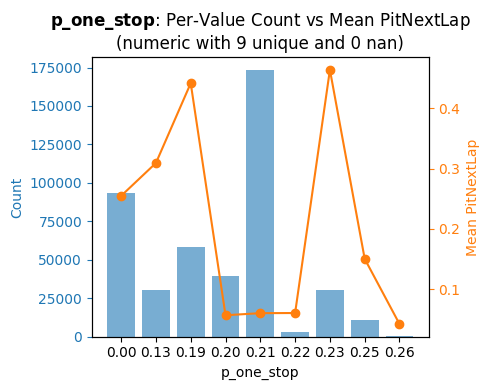

In [9]:
plot_features_dual_axis(train, cols=['p_one_stop'], target_col='PitNextLap', n_bins=15, n_wide=1)

## pit_window_cdf

Per Race, Year, Compound: of all the pits that happened in the group, what fraction came at a TyreLife at or below this row's. A value near 1.0 means almost everyone on this compound at this circuit has already pitted by this tire age. That puts the row deep in the pit window.

In [10]:
def _pit_cdf(g):
    pits = g.loc[g['PitNextLap'] == 1, 'TyreLife'].values
    if len(pits) == 0:
        return pd.Series(np.nan, index=g.index)
    return pd.Series((pits[None, :] <= g['TyreLife'].values[:, None]).mean(axis=1), index=g.index)

train['pit_window_cdf'] = train.groupby(['Race', 'Year', 'Compound'], group_keys=False).apply(_pit_cdf)
train['pit_window_cdf'] = train['pit_window_cdf'].fillna(train['pit_window_cdf'].mean())

# Test rows look up their CDF position against train's sorted pit-lap TyreLifes.
train_pits = (train.loc[train['PitNextLap'] == 1]
              .groupby(['Race', 'Year', 'Compound'])['TyreLife']
              .apply(lambda s: np.sort(s.values)))

def _cdf_test(g):
    arr = train_pits.get(g.name)
    if arr is None or len(arr) == 0:
        return pd.Series(np.nan, index=g.index)
    return pd.Series(np.searchsorted(arr, g['TyreLife'].values, side='right') / len(arr), index=g.index)

test['pit_window_cdf'] = test.groupby(['Race', 'Year', 'Compound'], group_keys=False).apply(_cdf_test)
test['pit_window_cdf'] = test['pit_window_cdf'].fillna(train['pit_window_cdf'].mean())

C:\Users\yoavi\AppData\Local\Temp\claude\ipykernel_29324\1589711012.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train['pit_window_cdf'] = train.groupby(['Race', 'Year', 'Compound'], group_keys=False).apply(_pit_cdf)


C:\Users\yoavi\AppData\Local\Temp\claude\ipykernel_29324\1589711012.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test['pit_window_cdf'] = test.groupby(['Race', 'Year', 'Compound'], group_keys=False).apply(_cdf_test)


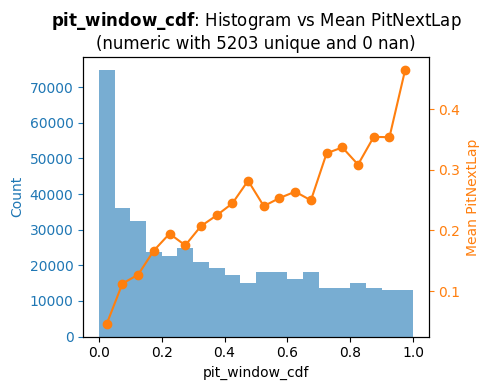

In [11]:
plot_features_dual_axis(train, cols=['pit_window_cdf'], target_col='PitNextLap', n_bins=20, n_wide=1)

## compound_stint_pit_rate

A small 5 by 8 lookup. I took the mean PitNextLap for every Compound and Stint combo and mapped it onto each row. It encodes interactions like MEDIUM in Stint 2 against HARD in Stint 1 as one number.

In [12]:
pit_rate = train.groupby(['Compound', 'Stint'])['PitNextLap'].mean()
train['compound_stint_pit_rate'] = train.set_index(['Compound', 'Stint']).index.map(pit_rate).to_numpy()
test['compound_stint_pit_rate']  = test.set_index(['Compound', 'Stint']).index.map(pit_rate).to_numpy()
pit_rate.unstack()

Stint,1,2,3,4,5,6,7,8
Compound,,,,,,,,
HARD,0.075146,0.384432,0.320370,0.238323,0.122148,0.041667,0.0,NaN
INTERMEDIATE,0.099654,0.329996,0.359726,0.036982,0.134021,0.024242,0.0,0.023256
MEDIUM,0.035261,0.447699,0.278137,0.136611,0.053333,0.000000,0.0,0.000000
SOFT,0.246978,0.195639,0.136995,0.176631,0.026464,0.005319,0.0,0.000000
WET,0.020408,0.258065,NaN,0.000000,0.000000,0.000000,NaN,NaN


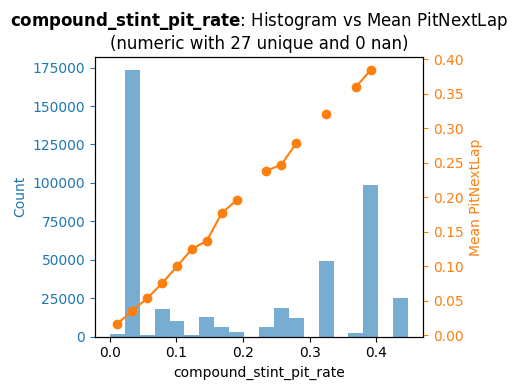

In [13]:
plot_features_dual_axis(train, cols=['compound_stint_pit_rate'], target_col='PitNextLap', n_bins=20, n_wide=1)

## prev_lap_time_delta

The previous sampled lap's LapTime_Delta within the same Race, Year, Driver, Stint. I sorted train and test together so a test row's previous lap can be a train row from the same driver-stint. Only the ordering crosses the split, no labels. I also tried prev_position_change, prev_tyre_life, rolling_lap_time_mean3, and gap_to_fastest_lap, then dropped them. See the rejection note at the end.

In [14]:
combined = pd.concat([train.assign(_split='tr'), test.assign(_split='te')], ignore_index=True, sort=False)
combined = combined.sort_values(['Race', 'Year', 'Driver', 'Stint', 'LapNumber']).reset_index(drop=True)
combined['prev_lap_time_delta'] = combined.groupby(['Race', 'Year', 'Driver', 'Stint'])['LapTime_Delta'].shift(1)

train = train.merge(combined.loc[combined['_split'] == 'tr', ['id', 'prev_lap_time_delta']], on='id', how='left')
test  = test.merge( combined.loc[combined['_split'] == 'te', ['id', 'prev_lap_time_delta']], on='id', how='left')

fill = train['prev_lap_time_delta'].mean()
train['prev_lap_time_delta'] = train['prev_lap_time_delta'].fillna(fill)
test['prev_lap_time_delta']  = test['prev_lap_time_delta'].fillna(fill)

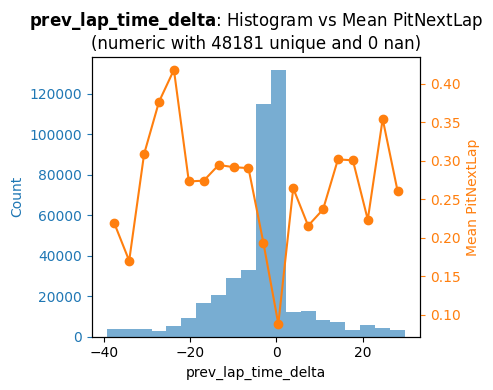

In [15]:
# clip 1st–99th percentile for display — extreme pit-out/pit-in laps would otherwise compress the bins
lo, hi = train['prev_lap_time_delta'].quantile([0.01, 0.99])
m = train['prev_lap_time_delta'].between(lo, hi)
plot_features_dual_axis(train[m], cols=['prev_lap_time_delta'], target_col='PitNextLap', n_bins=20, n_wide=1)

## Generator artifact features

The dataset is synthetic, built from real F1 lap data. Synthetic generators tend to keep the upper digits of a number and perturb the trailing decimals. If so, the trailing digits might carry nothing, or certain digit values might line up with rows the generator treated differently, like target-flipped rows. Same idea for TyreLife. It was originally an integer, so any non-integer value here is an artifact.

A flat orange line across digits means no tell at that decimal. A spike for some digit values means the generator is leaking signal I can use.

In [16]:
for df_ in (train, test):
    lt = df_['LapTime (s)']
    df_['laptime_tenths']      = (np.floor(lt * 10) % 10).astype(int)
    df_['laptime_hundredths']  = (np.floor(lt * 100) % 10).astype(int)
    df_['laptime_thousandths'] = (np.floor(lt * 1000) % 10).astype(int)
    tl = df_['TyreLife']
    df_['tyrelife_is_integer'] = (np.abs(tl - np.round(tl)) < 1e-6).astype(int)

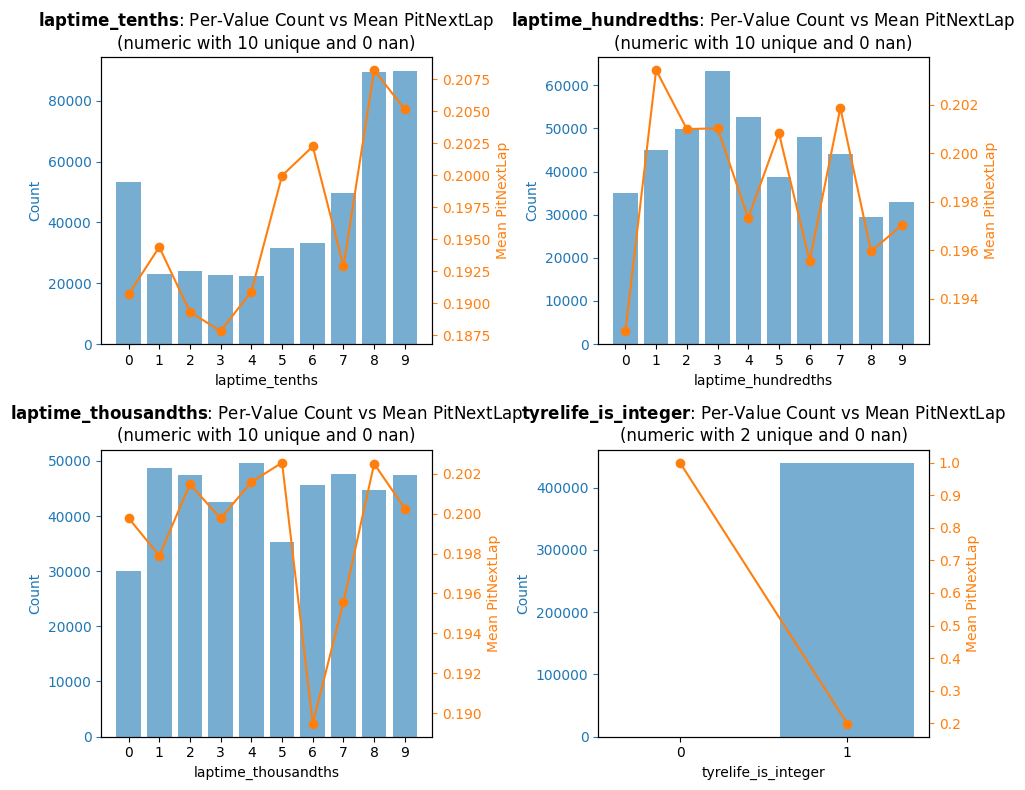

In [17]:
# all four are low-cardinality (digits 0-9, or 0/1) → dual-axis treats them as categorical, one bar per value
plot_features_dual_axis(
    train,
    cols=['laptime_tenths', 'laptime_hundredths', 'laptime_thousandths', 'tyrelife_is_integer'],
    target_col='PitNextLap',
    n_bins=10,
    n_wide=2,
)

## Nearest-real-lap features (kDTree on collected.csv)

For every synthetic row I found the closest real FastF1 lap in the same Race and Year, then attached two features:

- nearest_real_pitnextlap, the real lap's actual PitNextLap
- nearest_real_distance, the Euclidean distance to that real lap in standardized space

Matching used TyreLife, LapNumber, Position, LapTime (s), RaceProgress, Stint. Each Race-Year group got its own StandardScaler so distances are race-relative. Exact-key matching only covered about 14 percent of rows. This attaches a value to every row. The distance says how far a synthetic row drifted from any real lap, which is a useful artifact detector. Race-years missing from FastF1, mostly 2024, got column-mean fill.

In [18]:
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler

collected = pd.read_csv('data/collected.csv')
TREE_FEATS = ['TyreLife', 'LapNumber', 'Position', 'LapTime (s)', 'RaceProgress', 'Stint']
# Drop FastF1 rows missing any tree feature (DNFs / lapped cars / pit-laps). cKDTree errors on NaN.
collected = collected.dropna(subset=TREE_FEATS).reset_index(drop=True)

def attach_nearest(df):
    df = df.reset_index(drop=True).copy()
    nn_label = np.full(len(df), np.nan)
    nn_dist  = np.full(len(df), np.nan)
    for (race, year), real_grp in collected.groupby(['Race', 'Year']):
        synth_idx = df.index[(df['Race'] == race) & (df['Year'] == year)].to_numpy()
        if len(synth_idx) == 0 or len(real_grp) < 2:
            continue
        scaler = StandardScaler().fit(real_grp[TREE_FEATS].values)
        tree   = cKDTree(scaler.transform(real_grp[TREE_FEATS].values))
        dists, idxs = tree.query(scaler.transform(df.loc[synth_idx, TREE_FEATS].values), k=1)
        nn_label[synth_idx] = real_grp['PitNextLap'].values[idxs]
        nn_dist[synth_idx]  = dists
    df['nearest_real_pitnextlap'] = nn_label
    df['nearest_real_distance']   = nn_dist
    df['nearest_real_pitnextlap'] = df['nearest_real_pitnextlap'].fillna(df['nearest_real_pitnextlap'].mean())
    df['nearest_real_distance']   = df['nearest_real_distance'].fillna(df['nearest_real_distance'].mean())
    return df

train = attach_nearest(train)
test  = attach_nearest(test)
print('coverage — train:', train['nearest_real_pitnextlap'].notna().mean(),
      ' test:', test['nearest_real_pitnextlap'].notna().mean())

coverage — train: 1.0  test: 1.0


## Rank and frequency features

Two features for position within the field this lap, which nothing above captures:

- lap_time_pct_in_lap, the percentile rank of LapTime (s) across all drivers on the same Race, Year, LapNumber, bounded 0 to 1. A value of 0.95 means slower than 95 percent of the field, usually a worn-tire signal. Trees cannot derive this from raw LapTime since it compares across rows.
- same_compound_drivers_this_lap, the count of drivers on the same compound. It encodes strategic uniqueness, popular compound against off-strategy.

I computed both on combined train and test, percentile and count math only, no labels crossing the split.

In [19]:
combined = pd.concat([train.assign(_split='tr'), test.assign(_split='te')], ignore_index=True, sort=False)

combined['lap_time_pct_in_lap'] = combined.groupby(['Race', 'Year', 'LapNumber'])['LapTime (s)'].rank(pct=True)
combined['same_compound_drivers_this_lap'] = combined.groupby(['Race', 'Year', 'LapNumber', 'Compound'])['id'].transform('count')

new_cols = ['lap_time_pct_in_lap', 'same_compound_drivers_this_lap']
train = train.drop(columns=new_cols, errors='ignore').merge(
    combined.loc[combined['_split'] == 'tr', ['id'] + new_cols], on='id', how='left')
test  = test.drop( columns=new_cols, errors='ignore').merge(
    combined.loc[combined['_split'] == 'te', ['id'] + new_cols], on='id', how='left')

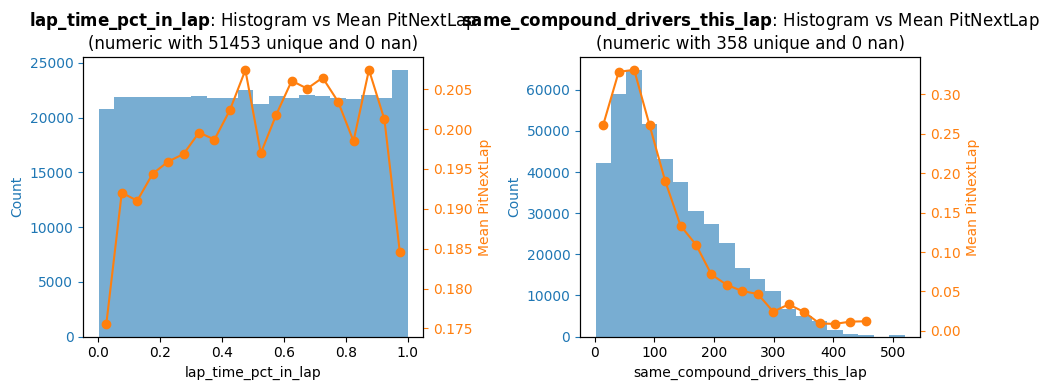

In [20]:
# lap_time_pct_in_lap is continuous [0,1] -> 20 bins; same_compound_drivers_this_lap is
# a small integer count -> dual-axis treats it as categorical (one bar per value).
plot_features_dual_axis(
    train,
    cols=['lap_time_pct_in_lap', 'same_compound_drivers_this_lap'],
    target_col='PitNextLap',
    n_bins=20,
    n_wide=2,
)

## Additional feature families (aggregates, lags, interactions)

The features above were curated for interpretability. The next families are bulk performance features: aggregates over the field, the stint, the driver-race, and the compound, an expanded lag and rolling set, arithmetic interactions, and percentile and bin encodings. Most rank low on permutation importance on their own. But permutation underrates correlated features, and together they recovered about 0.004 OOF AUC in earlier runs. I built them on combined train and test, features only, and let the modelling notebook prune them by importance.

In [21]:
combined = pd.concat([train.assign(_split='tr'), test.assign(_split='te')], ignore_index=True, sort=False)
combined = combined.sort_values(['Race', 'Year', 'Driver', 'Stint', 'LapNumber']).reset_index(drop=True)
existing = set(train.columns)

# --- Cross-driver, same lap (lap_time_pct_in_lap & same_compound_drivers_this_lap already exist) ---
lap_grp = combined.groupby(['Race', 'Year', 'LapNumber'])
combined['lap_lap_time_mean']   = lap_grp['LapTime (s)'].transform('mean')
combined['lap_lap_time_median'] = lap_grp['LapTime (s)'].transform('median')
combined['lap_lap_time_min']    = lap_grp['LapTime (s)'].transform('min')
combined['lap_lap_time_max']    = lap_grp['LapTime (s)'].transform('max')
combined['lap_lap_time_std']    = lap_grp['LapTime (s)'].transform('std')
combined['gap_to_lap_mean']     = combined['LapTime (s)'] - combined['lap_lap_time_mean']
combined['gap_to_lap_median']   = combined['LapTime (s)'] - combined['lap_lap_time_median']
combined['gap_to_fastest_lap']  = combined['LapTime (s)'] - combined['lap_lap_time_min']
combined['lap_time_rank_in_lap'] = lap_grp['LapTime (s)'].rank(method='dense')
combined['lap_tyre_life_mean']   = lap_grp['TyreLife'].transform('mean')
combined['lap_tyre_life_median'] = lap_grp['TyreLife'].transform('median')
combined['my_tyre_life_vs_lap_median'] = combined['TyreLife'] - combined['lap_tyre_life_median']
combined['drivers_in_lap']       = lap_grp['id'].transform('count')

# --- Within-stint aggregates ---
stint_grp = combined.groupby(['Race', 'Year', 'Driver', 'Stint'])
combined['stint_lap_time_mean']       = stint_grp['LapTime (s)'].transform('mean')
combined['stint_lap_time_std']        = stint_grp['LapTime (s)'].transform('std')
combined['stint_lap_time_min']        = stint_grp['LapTime (s)'].transform('min')
combined['stint_lap_time_max']        = stint_grp['LapTime (s)'].transform('max')
combined['stint_lap_time_delta_mean'] = stint_grp['LapTime_Delta'].transform('mean')
combined['stint_lap_time_delta_std']  = stint_grp['LapTime_Delta'].transform('std')
combined['stint_cum_deg_mean']        = stint_grp['Cumulative_Degradation'].transform('mean')
combined['stint_cum_deg_std']         = stint_grp['Cumulative_Degradation'].transform('std')
combined['stint_position_mean']       = stint_grp['Position'].transform('mean')
combined['stint_position_change_sum'] = stint_grp['Position_Change'].transform('sum')
combined['stint_rows_count']          = stint_grp['id'].transform('count')

# --- Within-race-driver aggregates ---
dr_grp = combined.groupby(['Race', 'Year', 'Driver'])
combined['driver_race_lap_time_mean']     = dr_grp['LapTime (s)'].transform('mean')
combined['driver_race_lap_time_std']      = dr_grp['LapTime (s)'].transform('std')
combined['driver_race_lap_time_min']      = dr_grp['LapTime (s)'].transform('min')
combined['driver_race_position_mean']     = dr_grp['Position'].transform('mean')
combined['driver_race_position_std']      = dr_grp['Position'].transform('std')
combined['driver_race_max_stint']         = dr_grp['Stint'].transform('max')
combined['driver_race_pit_count']         = combined['driver_race_max_stint'] - 1
combined['driver_race_lap_count']         = dr_grp['id'].transform('count')
combined['driver_race_position_change_sum'] = dr_grp['Position_Change'].transform('sum')
combined['driver_race_compound_count']    = dr_grp['Compound'].transform('nunique')

# --- Compound-specific aggregates ---
rc_grp = combined.groupby(['Race', 'Year', 'Compound'])
combined['race_compound_lap_time_mean']  = rc_grp['LapTime (s)'].transform('mean')
combined['race_compound_tyre_life_mean'] = rc_grp['TyreLife'].transform('mean')
combined['race_compound_driver_count']   = rc_grp['Driver'].transform('nunique')
combined['race_compound_row_count']      = rc_grp['id'].transform('count')

# --- Lag / rolling expansion (5 columns x lag1/lag2/diff1/roll3_mean/roll3_std) ---
lag_g = combined.groupby(['Race', 'Year', 'Driver', 'Stint'])
for col, safe in [('LapTime (s)', 'laptime'), ('LapTime_Delta', 'ltdelta'),
                  ('Position', 'position'), ('TyreLife', 'tyrelife'),
                  ('Cumulative_Degradation', 'cumdeg')]:
    lag1 = lag_g[col].shift(1)
    lag2 = lag_g[col].shift(2)
    combined[f'lag1_{safe}'] = lag1
    combined[f'lag2_{safe}'] = lag2
    combined[f'diff1_{safe}'] = combined[col] - lag1
    stacked = pd.concat([combined[col], lag1, lag2], axis=1)
    combined[f'roll3_mean_{safe}'] = stacked.mean(axis=1)
    combined[f'roll3_std_{safe}']  = stacked.std(axis=1)

# --- Interactions ---
combined['tyrelife_x_stint']        = combined['TyreLife'] * combined['Stint']
combined['tyrelife_x_lapnumber']    = combined['TyreLife'] * combined['LapNumber']
combined['tyrelife_x_raceprogress'] = combined['TyreLife'] * combined['RaceProgress']
combined['tyrelife_div_lapnumber']  = combined['TyreLife'] / combined['LapNumber'].replace(0, np.nan)
combined['stint_x_raceprogress']    = combined['Stint'] * combined['RaceProgress']
combined['lapnumber_x_raceprogress'] = combined['LapNumber'] * combined['RaceProgress']
combined['ltdelta_x_tyrelife']      = combined['LapTime_Delta'] * combined['TyreLife']
combined['position_x_raceprogress'] = combined['Position'] * combined['RaceProgress']
combined['cumdeg_div_tyrelife']     = combined['Cumulative_Degradation'] / combined['TyreLife'].replace(0, np.nan)
combined['cumdeg_div_lapnumber']    = combined['Cumulative_Degradation'] / combined['LapNumber'].replace(0, np.nan)
combined['pitwindow_x_lapsremfrac'] = combined['pit_window_cdf'] * combined['laps_remaining_frac']
combined['stintprog_x_ponestop']    = combined['stint_progress'] * combined['p_one_stop']

# --- Percentile / binning ---
combined['tyrelife_pct_in_compound']      = combined.groupby('Compound')['TyreLife'].rank(pct=True)
combined['tyrelife_pct_in_stint']         = combined.groupby('Stint')['TyreLife'].rank(pct=True)
combined['tyrelife_pct_in_race_compound'] = combined.groupby(['Race', 'Year', 'Compound'])['TyreLife'].rank(pct=True)
combined['laptime_pct_in_compound']       = combined.groupby('Compound')['LapTime (s)'].rank(pct=True)
combined['position_pct_in_race']          = combined.groupby(['Race', 'Year'])['Position'].rank(pct=True)
combined['cumdeg_pct_in_stint']           = combined.groupby(['Race', 'Year', 'Driver', 'Stint'])['Cumulative_Degradation'].rank(pct=True)
combined['raceprogress_decile']           = pd.cut(combined['RaceProgress'], bins=10, labels=False)
combined['tyrelife_decile_in_compound']   = (combined.groupby('Compound')['TyreLife'].rank(pct=True) * 10).clip(upper=9.999).astype(int)
combined['position_bucket3']              = pd.cut(combined['Position'], bins=[0, 6, 15, 25], labels=False, include_lowest=True)

# Merge the new columns back onto train/test and fill any NaNs with the train mean.
new_cols = [c for c in combined.columns if c not in existing and c != '_split']
train = train.merge(combined.loc[combined['_split'] == 'tr', ['id'] + new_cols], on='id', how='left')
test  = test.merge( combined.loc[combined['_split'] == 'te', ['id'] + new_cols], on='id', how='left')
for c in new_cols:
    fill = train[c].mean()
    train[c] = train[c].fillna(fill)
    test[c]  = test[c].fillna(fill)
print(f'added {len(new_cols)} feature-family columns; train now {train.shape[1]} cols')

added 84 feature-family columns; train now 114 cols


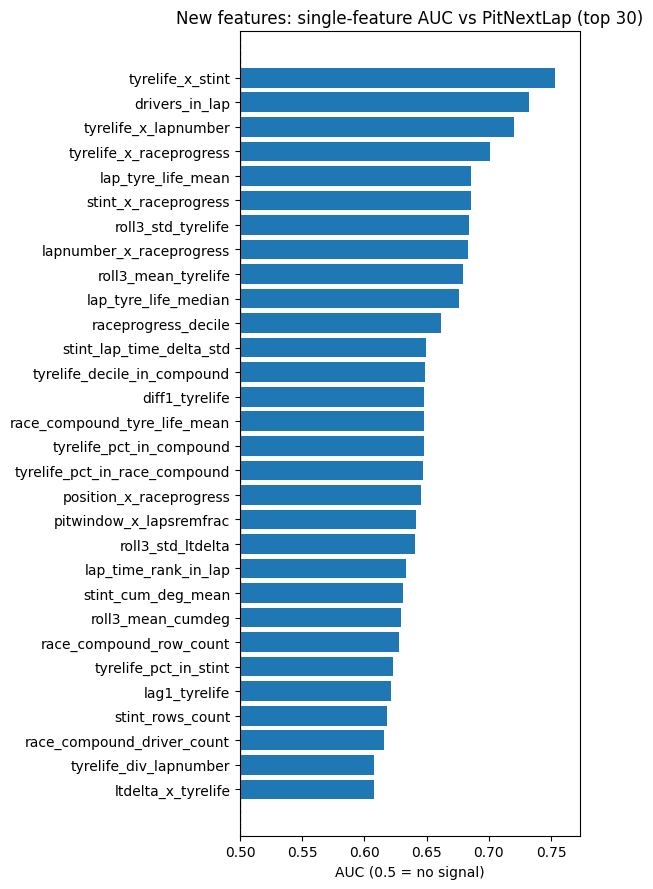

In [22]:
# Single-feature AUC of each new family feature vs PitNextLap (cheap signal check, no model).
from sklearn.metrics import roc_auc_score
rows = []
for c in new_cols:
    a = roc_auc_score(train['PitNextLap'], train[c].fillna(train[c].median()))
    rows.append((c, max(a, 1 - a)))   # flip anti-correlated features so all are >= 0.5
auc_df = pd.DataFrame(rows, columns=['feature', 'auc']).sort_values('auc', ascending=False)

top = auc_df.head(30)
plt.figure(figsize=(6, 9))
plt.barh(top['feature'], top['auc'])
plt.gca().invert_yaxis()
plt.axvline(0.5, color='grey', linestyle='--', linewidth=1)
plt.title('New features: single-feature AUC vs PitNextLap (top 30)')
plt.xlabel('AUC (0.5 = no signal)')
plt.xlim(0.5, max(0.55, top['auc'].max() + 0.02))
plt.tight_layout()
plt.show()

## Target encodings (computed inside the CV loop, not here)

Three more features: driver_pit_rate, driver_compound_pit_rate, race_compound_pit_rate. Each is a mean PitNextLap grouped by Driver, by Driver and Compound, and by Race and Compound. They use the target directly, so they have to be rebuilt inside each CV fold on the training-fold rows only, then mapped onto the validation fold and test. Doing it once here would leak the target into validation. They live in the modelling notebook.

## Save engineered features

I saved the full feature set to parquet. The modelling notebooks read it directly.

In [23]:
train.to_parquet('data/train_features.parquet')
test.to_parquet('data/test_features.parquet')
print(f'saved data/train_features.parquet  {train.shape}')
print(f'saved data/test_features.parquet   {test.shape}')


saved data/train_features.parquet  (439140, 114)
saved data/test_features.parquet   (188165, 113)
